## Loading dataset

Import necessary libraries and download the dataset.

In [ ]:
import pandas as pd
import numpy as np
import os
import sys
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import GridSearchCV, StratifiedKFold

sys.path.insert(0, os.path.abspath('..'))
from data_cleaning import load_and_clean

path = kagglehub.dataset_download("vicsuperman/prediction-of-music-genre")
print("Path to dataset files:", path)

## Data Cleaning and Encoding

#### Shared data cleaning (via `data_cleaning.py`)
Both group notebooks call the same `load_and_clean()` function to ensure identical preprocessing:
- Remove rows with bad values (`?`, `-1`, `'-1'`, empty strings, NaN) across all columns at once
- Convert `tempo` to float
- Remove exact full-row duplicates
- Remove conflicting duplicates: same `(artist_name, track_name)` with different categorical labels
- Drop metadata columns: `artist_name`, `track_name`, `instance_id`, `obtained_date`

In [ ]:
df = load_and_clean(os.path.join(path, "music_genre.csv"))
df.head()

Loaded:                      50,005 rows, 18 columns
After bad value removal:     40,560 rows
Exact duplicates removed:         0
Conflicting duplicates removed: 5,080
Final shape:                 (35480, 14)


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,31.0,0.01270,0.622,218293.0,0.890,0.950000,D,0.124,-7.043,Minor,0.0300,115.002,0.531,Electronic
1,28.0,0.00306,0.620,215613.0,0.755,0.011800,G#,0.534,-4.617,Major,0.0345,127.994,0.333,Electronic
2,34.0,0.02540,0.774,166875.0,0.700,0.002530,C#,0.157,-4.498,Major,0.2390,128.014,0.270,Electronic
3,32.0,0.00465,0.638,222369.0,0.587,0.909000,F#,0.157,-6.266,Major,0.0413,145.036,0.323,Electronic
4,46.0,0.02890,0.572,214408.0,0.803,0.000008,B,0.106,-4.294,Major,0.3510,149.995,0.230,Electronic


#### Data encoding and feature combinition
- 'mode' is the target column but it is not numerical. `LabelEncoder` sorts labels alphabetically, so it maps Major = 0, Minor = 1.
- Musical mode is highly related to the emotions, it is helpful for predictions to combine emotion-related variables to create new variables.
- 'key' in musical are ordered in sequence and has a cyclical nature, therefore, they can be encoded cyclically to represent this nature.

In [ ]:
label_encoder = LabelEncoder()
df["mode"] = label_encoder.fit_transform(df["mode"])

df["energy_danceability"] = df["energy"] * df["danceability"]
df["valence_danceability"] = df["valence"] * df["danceability"]
df["energy_valence"] = df["energy"] * df["valence"]

df["key"] = label_encoder.fit_transform(df["key"])
df["key_sin"] = np.sin(2 * np.pi * df["key"] / 12)
df["key_cos"] = np.cos(2 * np.pi * df["key"] / 12)
df = df.drop(columns=["key"])

# Ensure a continuous index after row filtering so later assignments align by row position.
df = df.reset_index(drop=True)
df.head()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,mode,speechiness,tempo,valence,music_genre,energy_danceability,valence_danceability,energy_valence,key_sin,key_cos
0,31.0,0.01270,0.622,218293.0,0.890,0.950000,0.124,-7.043,1,0.0300,115.002,0.531,Electronic,0.553580,0.330282,0.472590,0.500000,-8.660254e-01
1,28.0,0.00306,0.620,215613.0,0.755,0.011800,0.534,-4.617,0,0.0345,127.994,0.333,Electronic,0.468100,0.206460,0.251415,-0.500000,8.660254e-01
2,34.0,0.02540,0.774,166875.0,0.700,0.002530,0.157,-4.498,0,0.2390,128.014,0.270,Electronic,0.541800,0.208980,0.189000,0.866025,-5.000000e-01
3,32.0,0.00465,0.638,222369.0,0.587,0.909000,0.157,-6.266,0,0.0413,145.036,0.323,Electronic,0.374506,0.206074,0.189601,-1.000000,-1.836970e-16
4,46.0,0.02890,0.572,214408.0,0.803,0.000008,0.106,-4.294,0,0.3510,149.995,0.230,Electronic,0.459316,0.131560,0.184690,0.866025,5.000000e-01


## Data Visualisation

Class distribution: Major vs Minor

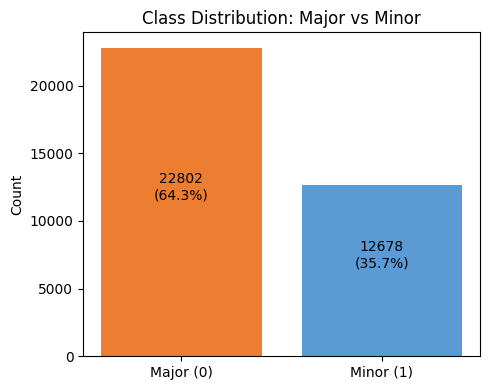

In [ ]:
# LabelEncoder maps alphabetically: Major=0, Minor=1
mode_counts = df["mode"].value_counts().sort_index()
labels = ["Major (0)", "Minor (1)"]
colors = ["#ED7D31", "#5B9BD5"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, mode_counts.values, color=colors)
ax.set_title("Class Distribution: Major vs Minor")
ax.set_ylabel("Count")
for bar, count in zip(bars, mode_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_center()[1],
        f"{count}\n({count / len(df) * 100:.1f}%)",
        ha="center", va="bottom"
    )
plt.tight_layout()
plt.show()

Box plots of each continuous feature grouped by mode

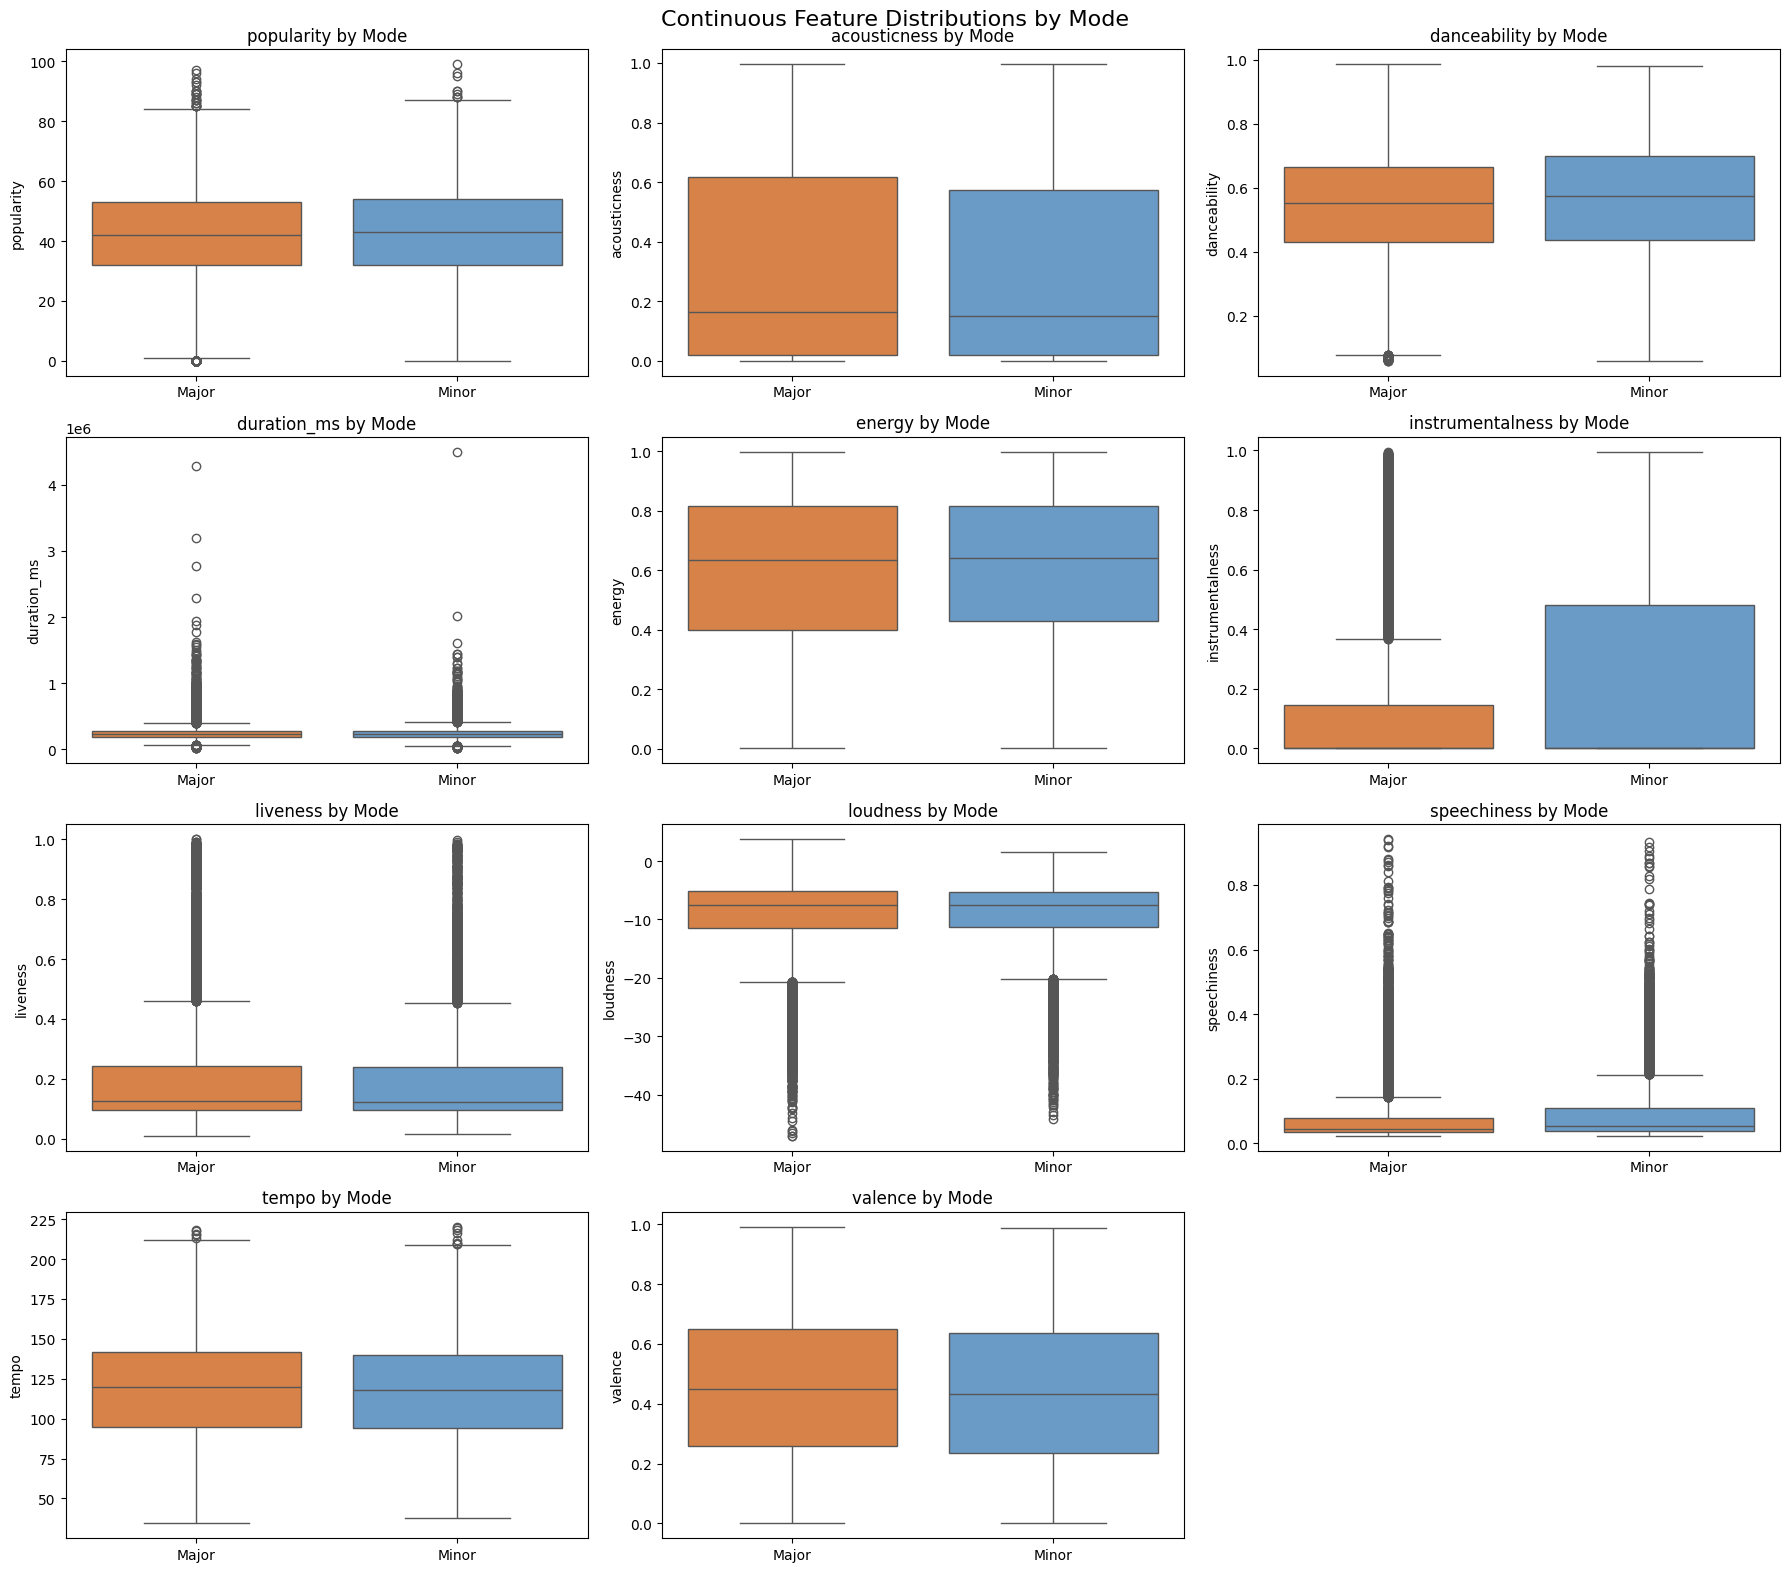

In [ ]:
continuous_features = [
    "popularity", "acousticness", "danceability", "duration_ms",
    "energy", "instrumentalness", "liveness", "loudness",
    "speechiness", "tempo", "valence"
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.boxplot(
        data=df, x="mode", y=feature, ax=axes[i],
        palette=["#ED7D31", "#5B9BD5"], hue="mode", legend=False
    )
    axes[i].set_title(f"{feature} by Mode")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Major", "Minor"])
    axes[i].set_xlabel("")

fig.delaxes(axes[11])
plt.suptitle("Continuous Feature Distributions by Mode", fontsize=16)
plt.tight_layout()
plt.show()

Major/Minor counts per genre

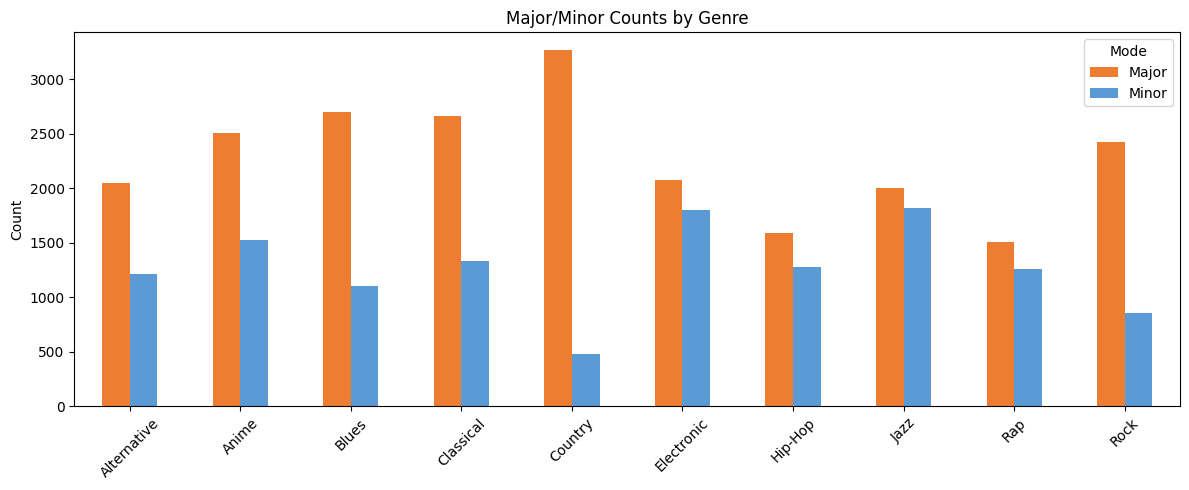

In [ ]:
genre_mode = df.groupby(["music_genre", "mode"]).size().unstack(fill_value=0)
genre_mode.columns = ["Major", "Minor"]
genre_mode_pct = genre_mode.div(genre_mode.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
genre_mode.plot(kind="bar", ax=ax, color=["#ED7D31", "#5B9BD5"])
ax.set_title("Major/Minor Counts by Genre")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Mode", loc="upper right")
plt.tight_layout()
plt.show()

Major/Minor counts per key

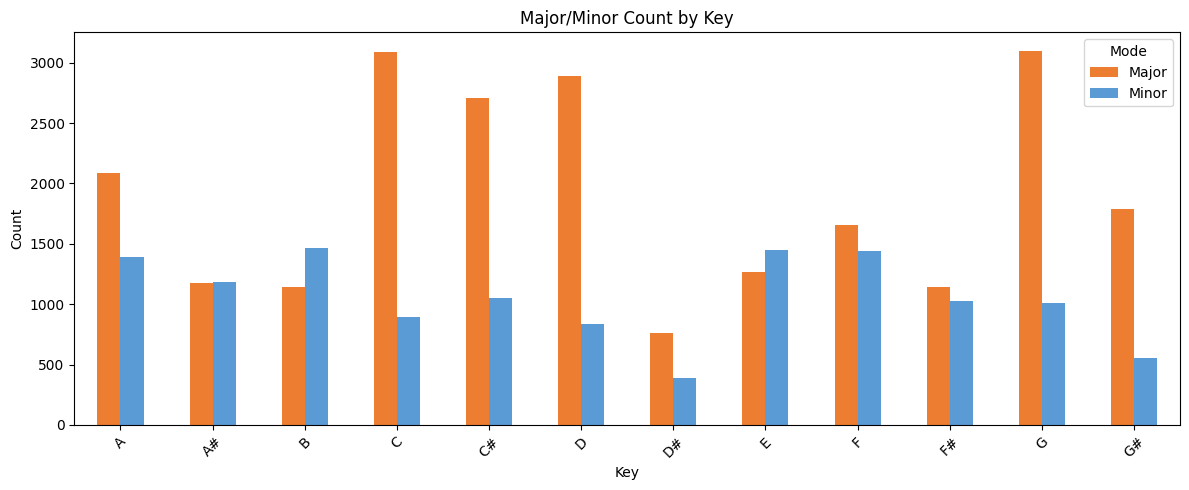

In [ ]:
# Recover key names from cyclical encoding
# key_int = round(arctan2(sin, cos) * 12 / 2π) % 12 reverses the sin/cos transform
key_names = ['A', 'A#', 'B', 'C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#']
key_int = np.round(np.arctan2(df["key_sin"], df["key_cos"]) * 12 / (2 * np.pi)).astype(int) % 12
df_vis = df.copy()
df_vis["key_name"] = key_int.map(dict(enumerate(key_names)))

key_mode = df_vis.groupby(["key_name", "mode"]).size().unstack(fill_value=0)
key_mode.columns = ["Major", "Minor"]
key_mode = key_mode.reindex(key_names)  # order keys musically (A through G#)
key_mode_pct = key_mode.div(key_mode.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))

key_mode.plot(kind="bar", ax=ax, color=["#ED7D31", "#5B9BD5"])
ax.set_title("Major/Minor Count by Key")
ax.set_xlabel("Key")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Mode")

plt.tight_layout()
plt.show()

Correlation heatmap of all numeric features after encoding

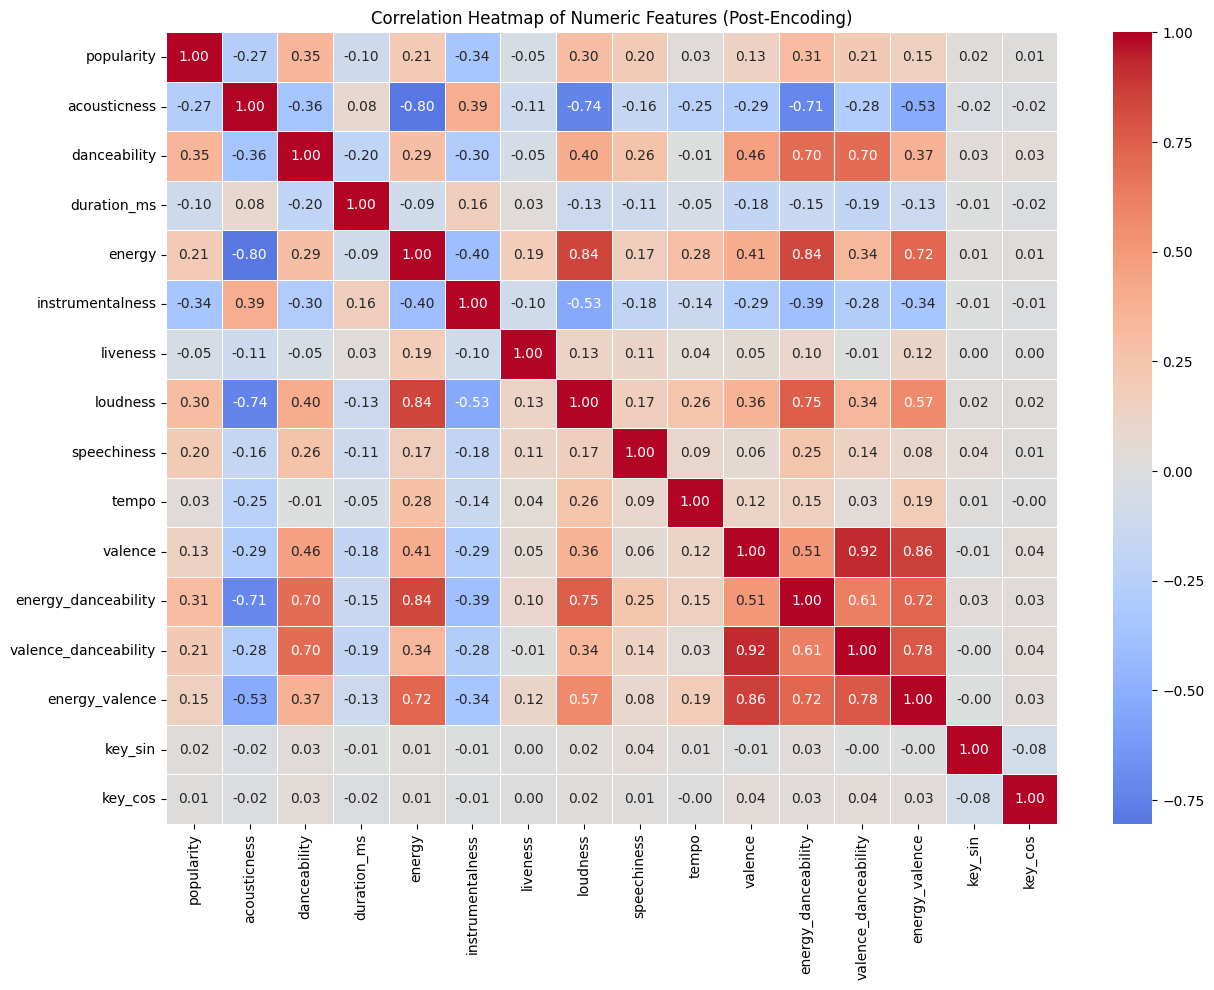

In [ ]:
numeric_cols = df.select_dtypes(include="number").drop(columns=["mode"]).columns

plt.figure(figsize=(13, 10))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, cmap="coolwarm", fmt=".2f", center=0, linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features (Post-Encoding)")
plt.tight_layout()
plt.show()

## Data Stratification
Stratify with 70% train and 30% test to maintain class balance

In [ ]:
X = df.drop(columns=["mode"])
y = df["mode"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## Feature Selection
Compute mutual information against `mode`, it measures how much knowing a feature reduces uncertainty about `mode`. 

                Feature  MI Score
                    key  0.033293
    music_genre_Country  0.016529
            speechiness  0.013000
                 energy  0.005751
                  tempo  0.005646
           danceability  0.005570
       instrumentalness  0.005219
       music_genre_Jazz  0.004146
             popularity  0.004112
    energy_danceability  0.003505
 music_genre_Electronic  0.003232
           acousticness  0.003002
               loudness  0.002472
         energy_valence  0.002414
       music_genre_Rock  0.002377
            duration_ms  0.002022
    music_genre_Hip-Hop  0.001577
               liveness  0.001577
        music_genre_Rap  0.001570
      music_genre_Blues  0.001146
  music_genre_Classical  0.000168
      music_genre_Anime  0.000090
music_genre_Alternative  0.000037
                valence  0.000000
   valence_danceability  0.000000


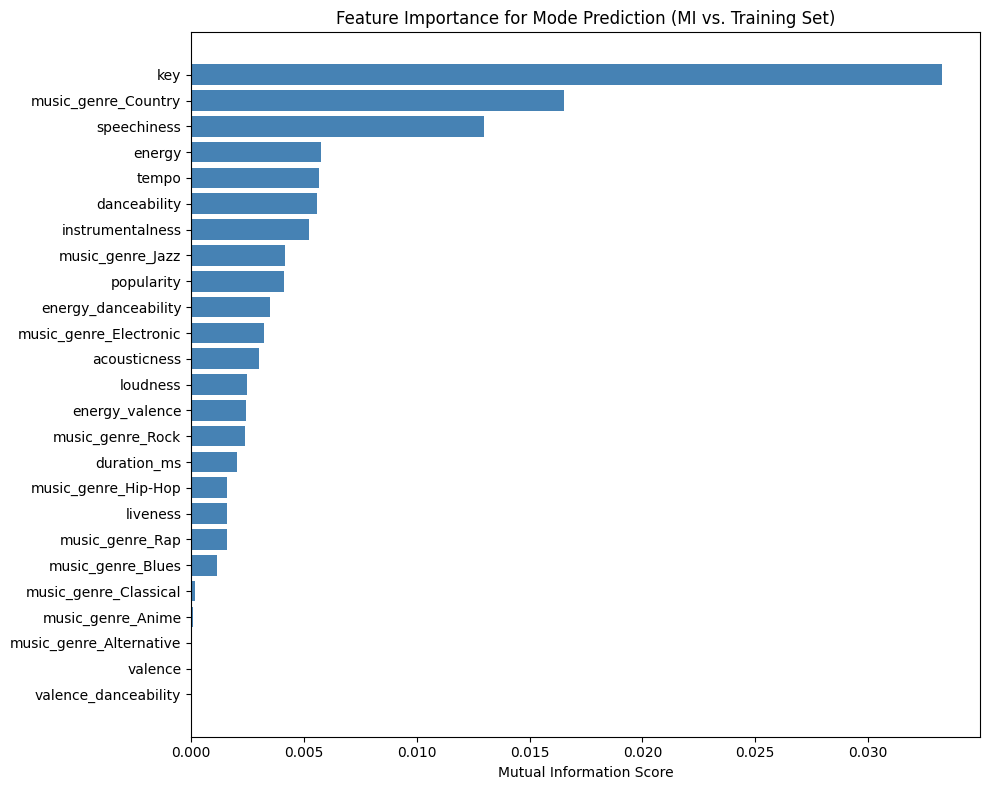

Selected features: ['popularity', 'danceability', 'energy', 'instrumentalness', 'speechiness', 'tempo', 'energy_danceability', 'music_genre_Country', 'music_genre_Jazz', 'key_sin', 'key_cos']


In [ ]:
# One-hot encode music_genre on train and test separately, then align columns
X_train_enc = pd.get_dummies(X_train, columns=["music_genre"])
X_test_enc = pd.get_dummies(X_test, columns=["music_genre"])

# For MI, key_sin and key_cos are recombined into a single discrete key integer,
# since together they encode one circular variable — computing MI on each separately
# gives two partial scores rather than one accurate measure of key's predictive value.
key_int_train = (
    np.round(np.arctan2(X_train_enc["key_sin"], X_train_enc["key_cos"]) * 12 / (2 * np.pi))
    .astype(int) % 12
)
X_mi = X_train_enc.drop(columns=["key_sin", "key_cos"]).copy()
X_mi["key"] = key_int_train

# Mark discrete features: one-hot genre columns and the recovered key integer
discrete_mask = [c.startswith("music_genre_") or c == "key" for c in X_mi.columns]

mi_scores = mutual_info_classif(X_mi, y_train, discrete_features=discrete_mask, random_state=42)
mi_df = pd.DataFrame({"Feature": X_mi.columns, "MI Score": mi_scores})
mi_df = mi_df.sort_values("MI Score", ascending=False).reset_index(drop=True)

print(mi_df.to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(mi_df["Feature"][::-1], mi_df["MI Score"][::-1], color="steelblue")
plt.xlabel("Mutual Information Score")
plt.title("Feature Importance for Mode Prediction (MI vs. Training Set)")
plt.tight_layout()
plt.show()

# SelectKBest uses the same discrete_mask to stay consistent with mi_df above
number_of_features = 10
selector = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, discrete_features=discrete_mask, random_state=42),
    k=number_of_features
)
selector.fit(X_mi, y_train)

# Get selected feature names, map 'key' back to key_sin/key_cos for model training
selected_features = X_mi.columns[selector.get_support()].tolist()
selected_cols = []
for f in selected_features:
    if f == "key":
        selected_cols += ["key_sin", "key_cos"]
    else:
        selected_cols.append(f)

print("Selected features:", selected_cols)

## Feature Scaling

#### The selected models (SVM, Logistic Regression, Neural Network) are all sensitive to feature scale, so `StandardScaler` is applied.

- Fit only on `X_train`, then transform `X_test` — prevents test statistics from leaking into training.
- `key_sin`/`key_cos` are already in [−1, 1] and are not scaled.
- One-hot encoded `music_genre` columns are 0 and 1, so not scaled.

In [ ]:
# Align ensures test has the same columns as train
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

no_scale_cols = [c for c in X_train_enc.columns
                 if c.startswith("music_genre_") or c in ["key_sin", "key_cos"]]
scale_cols = [c for c in X_train_enc.columns if c not in no_scale_cols]

# Fit scaler on X_train only, then transform both sets
scaler = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_test_scaled = X_test_enc.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train_enc[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test_enc[scale_cols])
X_train_selected = X_train_scaled[selected_cols]
X_test_selected = X_test_scaled[selected_cols]

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print(f"X_train_selected: {X_train_selected.shape}")
print(f"X_test_selected:  {X_test_selected.shape}")
X_train_scaled.head()

X_train_scaled: (24836, 26)
X_test_scaled:  (10644, 26)
X_train_selected: (24836, 11)
X_test_selected:  (10644, 11)


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,...,music_genre_Alternative,music_genre_Anime,music_genre_Blues,music_genre_Classical,music_genre_Country,music_genre_Electronic,music_genre_Hip-Hop,music_genre_Jazz,music_genre_Rap,music_genre_Rock
18939,2.956838,-0.722533,0.036912,-0.209153,-0.200038,-0.592822,0.016822,0.622163,-0.512631,0.781198,...,False,False,False,False,False,False,False,False,True,False
13035,1.398622,-0.870967,1.128687,-0.510235,0.248015,-0.592752,-0.511164,0.368697,2.520288,0.976061,...,True,False,False,False,False,False,False,False,False,False
14192,0.424738,0.017067,-1.060462,0.429112,-0.163312,0.049495,4.774837,-0.553806,-0.422315,0.059335,...,True,False,False,False,False,False,False,False,False,False
13383,-0.029741,1.110340,1.537403,-0.809985,0.685049,-0.592822,-0.707010,0.584369,1.543621,-0.911298,...,True,False,False,False,False,False,False,False,False,False
25822,0.814292,-0.676291,-0.220635,0.059444,0.284740,-0.592822,-0.191916,0.292485,-0.553588,0.135696,...,False,False,False,False,False,False,False,False,False,True


## Data Modeling without Feature Selection

Model Comparison Results:
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.5732     0.5865  0.5934 0.5690
                SVM    0.5581     0.5838  0.5888 0.5564


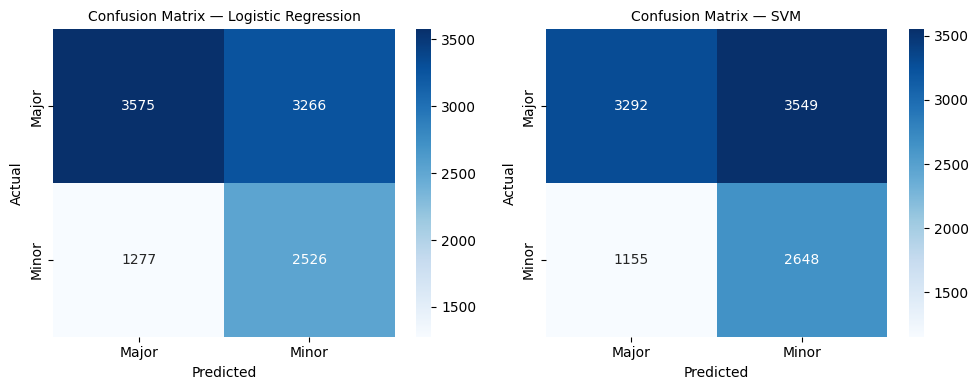

In [ ]:
models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
        "X_train": X_train_scaled,
        "X_test": X_test_scaled
    },
    "SVM": {
        "model": SVC(kernel="linear", random_state=42, class_weight="balanced"),
        "X_train": X_train_scaled,
        "X_test": X_test_scaled
    }
}

results = []
conf_matrices = {}
for name, info in models.items():
    model = info["model"]
    X_tr = info["X_train"]
    X_te = info["X_test"]

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)

    conf_matrices[name] = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4)
    })

results_df = pd.DataFrame(results)
print("Model Comparison Results:")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, matrix) in zip(axes, conf_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Major", "Minor"], yticklabels=["Major", "Minor"])
    ax.set_title(f"Confusion Matrix — {name}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Data Modeling with Feature Selection

See if feature selection helps to improve the models' performace.

Model Comparison Results (Top 10 MI Features):
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.5535     0.5678  0.5731 0.5494
                SVM    0.5372     0.5736  0.5759 0.5368


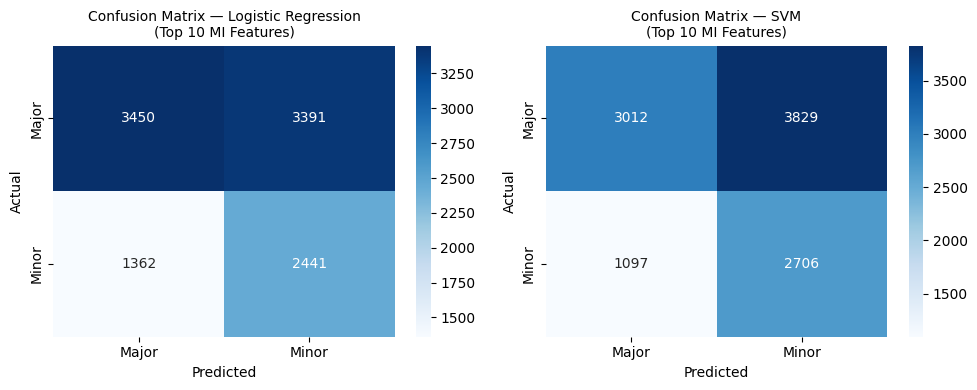

In [ ]:
models_sel = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
        "X_train": X_train_selected,
        "X_test": X_test_selected
    },
    "SVM": {
        "model": SVC(kernel="linear", random_state=42, class_weight="balanced"),
        "X_train": X_train_selected,
        "X_test": X_test_selected
    }
}

results_sel = []
conf_matrices_sel = {}
for name, info in models_sel.items():
    model = info["model"]
    X_tr = info["X_train"]
    X_te = info["X_test"]

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)

    conf_matrices_sel[name] = confusion_matrix(y_test, y_pred)

    results_sel.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4)
    })

results_sel_df = pd.DataFrame(results_sel)
print("Model Comparison Results (Top 10 MI Features):")
print(results_sel_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, matrix) in zip(axes, conf_matrices_sel.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Major", "Minor"], yticklabels=["Major", "Minor"])
    ax.set_title(f"Confusion Matrix — {name}\n(Top 10 MI Features)", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Neural Network without Feature Selection

In [ ]:
mlp = MLPClassifier(max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

acc_mlp  = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, average="macro", zero_division=0)
rec_mlp  = recall_score(y_test, y_pred_mlp, average="macro", zero_division=0)
f1_mlp   = f1_score(y_test, y_pred_mlp, average="macro", zero_division=0)

mlp_result = pd.DataFrame([{
    "Model": "MLP",
    "Accuracy": round(acc_mlp, 4),
    "Precision": round(prec_mlp, 4),
    "Recall": round(rec_mlp, 4),
    "F1": round(f1_mlp, 4)
}])

results_df = pd.concat([results_df, mlp_result], ignore_index=True)
print("Model Comparison Results (Including MLP):")
print(results_df.to_string(index=False))

Model Comparison Results (Including MLP):
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.5732     0.5865  0.5934 0.5690
                SVM    0.5581     0.5838  0.5888 0.5564
                MLP    0.6755     0.6417  0.6318 0.6349


## Neural Network with Feature Selection

In [ ]:
mlp = MLPClassifier(max_iter=500, random_state=42)
mlp.fit(X_train_selected, y_train)
y_pred_mlp = mlp.predict(X_test_selected)

acc_mlp  = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, average="macro", zero_division=0)
rec_mlp  = recall_score(y_test, y_pred_mlp, average="macro", zero_division=0)
f1_mlp   = f1_score(y_test, y_pred_mlp, average="macro", zero_division=0)

mlp_selected_result = pd.DataFrame([{
    "Model": "MLP",
    "Accuracy": round(acc_mlp, 4),
    "Precision": round(prec_mlp, 4),
    "Recall": round(rec_mlp, 4),
    "F1": round(f1_mlp, 4)
}])

# Remove previous MLP result and add the new one for selected features
results_df = results_df[results_df["Model"] != "MLP"]
results_df = pd.concat([results_df, mlp_selected_result], ignore_index=True)
print("Model Comparison Results (Including MLP):")
print(results_df.to_string(index=False))

Model Comparison Results (Including MLP):
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.5732     0.5865  0.5934 0.5690
                SVM    0.5581     0.5838  0.5888 0.5564
                MLP    0.6901     0.6589  0.6254 0.6292


## Hyperparameter Tuning
Select parameters that are most influencial to the models perfromance against the research question.

In [ ]:
# Stratified 5-fold CV preserves the 64/36 Major/Minor ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_specs = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
        # C controls regularisation strength: smaller values = stronger regularisation
        {"C": [0.01, 0.1, 1, 10]},
    ),
    "SVM": (
        SVC(class_weight="balanced", random_state=42),
        {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]},
    ),
    "MLP": (
        MLPClassifier(max_iter=2000, random_state=42),
        {"activation": ["relu", "tanh"],
         "hidden_layer_sizes": [(32,), (64, 32), (128, 64, 32)],
         "alpha": [0.0001, 0.001, 0.01]},
    ),
}

best_models = {}
tuning_results = []

for name, (estimator, grid) in search_specs.items():
    print(f"--- Tuning {name} ---")
    search = GridSearchCV(
        estimator=estimator,
        param_grid=grid,
        cv=cv,
        scoring="f1_macro",   # macro F1 weighs Major and Minor equally despite imbalance
        n_jobs=-1,             # parallelise across CPU cores
        refit=True,           # auto-refit best config on full training set after CV
    )
    search.fit(X_train_selected, y_train)

    best_models[name] = search.best_estimator_
    tuning_results.append({
        "Model": name,
        "Best Params": str(search.best_params_),
        "Best CV F1": round(search.best_score_, 4),
    })
    print(f"  Best params: {search.best_params_}")
    print(f"  Best CV F1:  {search.best_score_:.4f}\n")

tuning_df = pd.DataFrame(tuning_results)
print("Cross-Validation Tuning Summary:")
print(tuning_df.to_string(index=False))

--- Tuning Logistic Regression ---
  Best params: {'C': 0.01}
  Best CV F1:  0.5670

--- Tuning SVM ---
  Best params: {'C': 10, 'kernel': 'rbf'}
  Best CV F1:  0.6414

--- Tuning MLP ---
  Best params: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (32,)}
  Best CV F1:  0.6407

Cross-Validation Tuning Summary:
              Model                                                        Best Params  Best CV F1
Logistic Regression                                                        {'C': 0.01}      0.5670
                SVM                                         {'C': 10, 'kernel': 'rbf'}      0.6414
                MLP {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (32,)}      0.6407


## Final Evaluation on Held-out Test Set
Each tuned model (`best_models`) is evaluated on `X_test_selected`.

Final Test Set Results (Tuned Models):
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.5618     0.5694  0.5753 0.5558
                SVM    0.6561     0.6345  0.6416 0.6362
                MLP    0.6964     0.6678  0.6318 0.6363


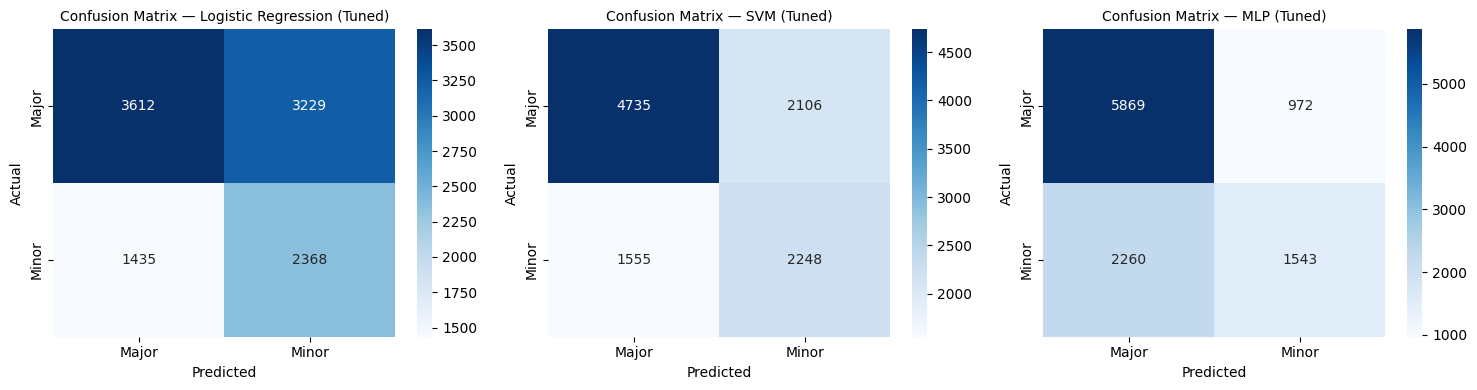

In [ ]:
final_results = []
final_conf_matrices = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test_selected)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)

    final_conf_matrices[name] = confusion_matrix(y_test, y_pred)
    final_results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
    })

final_df = pd.DataFrame(final_results)
print("Final Test Set Results (Tuned Models):")
print(final_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, matrix) in zip(axes, final_conf_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Major", "Minor"], yticklabels=["Major", "Minor"])
    ax.set_title(f"Confusion Matrix — {name} (Tuned)", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

Untuned vs Tuned (Selected Features, Test Set):
             Setting               Model  Accuracy  Precision  Recall     F1
Tuned (GridSearchCV) Logistic Regression    0.5618     0.5694  0.5753 0.5558
  Untuned (defaults) Logistic Regression    0.5535     0.5678  0.5731 0.5494
Tuned (GridSearchCV)                 MLP    0.6964     0.6678  0.6318 0.6363
  Untuned (defaults)                 MLP    0.6901     0.6589  0.6254 0.6292
Tuned (GridSearchCV)                 SVM    0.6561     0.6345  0.6416 0.6362
  Untuned (defaults)                 SVM    0.5372     0.5736  0.5759 0.5368

F1 Improvement:
Setting              Untuned (defaults)  Tuned (GridSearchCV)    Δ F1
Model                                                                
Logistic Regression              0.5494                0.5558  0.0064
MLP                              0.6292                0.6363  0.0071
SVM                              0.5368                0.6362  0.0994


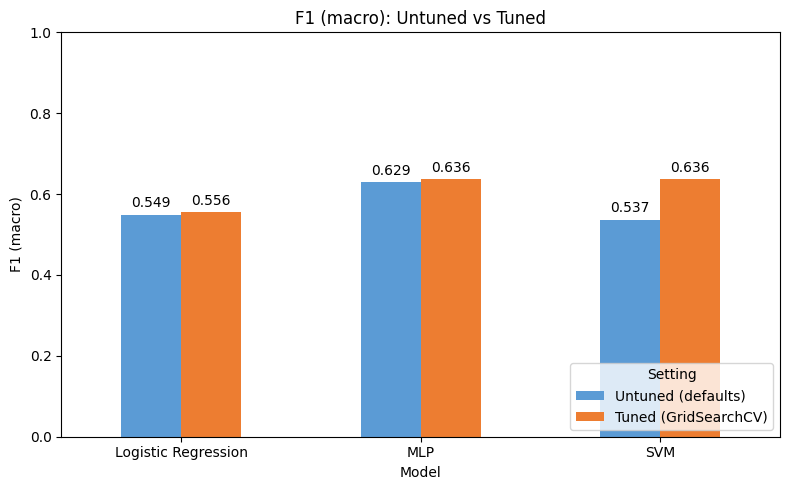

In [ ]:
untuned = pd.concat(
    [results_sel_df, results_df[results_df["Model"] == "MLP"]],
    ignore_index=True
)
untuned["Setting"] = "Untuned (defaults)"

tuned = final_df.copy()
tuned["Setting"] = "Tuned (GridSearchCV)"

# Side-by-side table
combined = pd.concat([untuned, tuned], ignore_index=True)
combined = combined[["Setting", "Model", "Accuracy", "Precision", "Recall", "F1"]]
combined = combined.sort_values(["Model", "Setting"]).reset_index(drop=True)
print("Untuned vs Tuned (Selected Features, Test Set):")
print(combined.to_string(index=False))

# F1 bar chart for visual comparison
pivot = combined.pivot(index="Model", columns="Setting", values="F1")
pivot = pivot[["Untuned (defaults)", "Tuned (GridSearchCV)"]]
pivot["Δ F1"] = pivot["Tuned (GridSearchCV)"] - pivot["Untuned (defaults)"]
print("\nF1 Improvement:")
print(pivot.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
pivot[["Untuned (defaults)", "Tuned (GridSearchCV)"]].plot(
    kind="bar", ax=ax, color=["#5B9BD5", "#ED7D31"]
)
ax.set_title("F1 (macro): Untuned vs Tuned")
ax.set_ylabel("F1 (macro)")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Setting", loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()